# 🔍 Employee Attrition Prediction: Identifying High-Risk Employees for Retention Strategy 📊


In this notebook, we will develop a machine learning model to predict employee attrition based on various features such as demographics, job information, performance, and more. The goal is to identify high-risk employees and provide valuable insights for creating targeted retention strategies.

## Step 1: Data Preprocessing 🧹 - Cleaning and Preparing the Employee Data for Analysis


In [1]:
# Importing essential libraries for data processing and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
# Load the dataset
df = pd.read_csv(r'C:\Users\kalpe\Downloads\Large_Engineering_HR_Employee_Attrition_with_Feedback.csv')

In [3]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,EmployeeFeedback
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Mechanical Engineering,1,1,...,80,0,8,0,1,5,4,0,5,I feel overworked and undervalued.
1,49,No,Travel_Frequently,279,Research & Development,8,1,Mechanical Engineering,1,2,...,80,1,10,3,3,9,7,1,7,I'm looking for more career growth opportunities.
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other Engineering,1,4,...,80,0,7,3,3,-1,0,0,0,There is a lack of communication from management.
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Mechanical Engineering,1,5,...,80,0,8,3,3,7,7,3,0,I feel my contributions are not being recognized.
4,27,No,Travel_Rarely,591,Research & Development,2,1,Electrical Engineering,1,7,...,80,1,6,3,3,1,2,2,2,The work-life balance is terrible.


C:\Users\kalpe\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


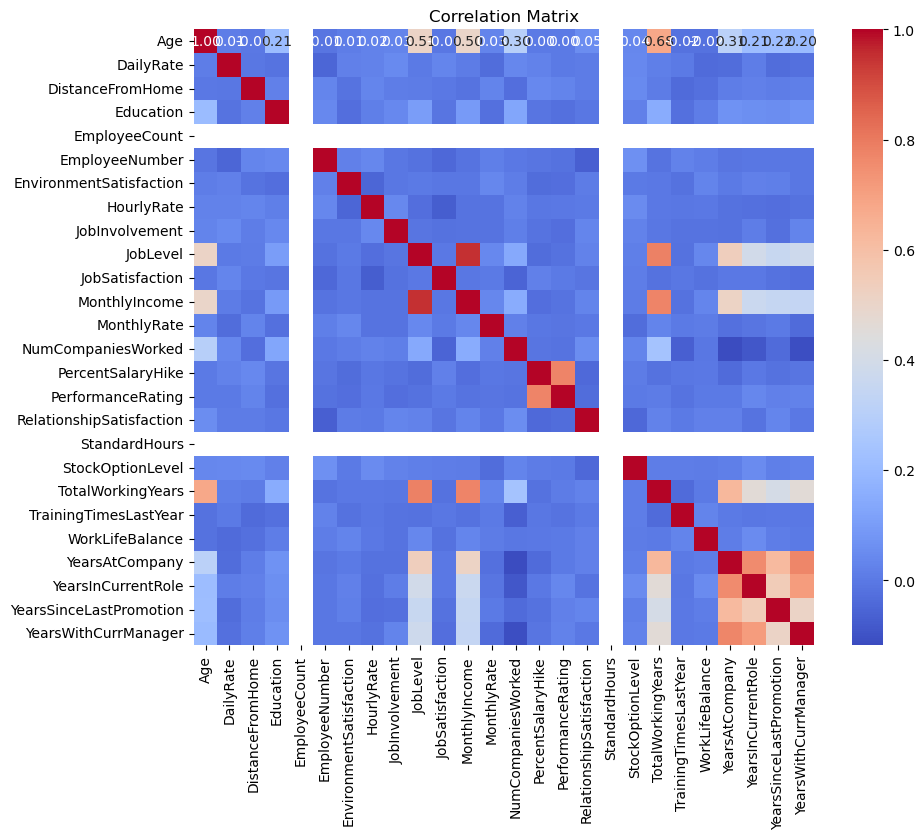

In [4]:
# Visualize the correlation matrix,This will give you an idea of how different features are related to each other.
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f", cbar=True)
plt.title('Correlation Matrix')
plt.show()

In [5]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [6]:
df[['EmployeeCount','Over18','StandardHours']].nunique()


EmployeeCount    1
Over18           1
StandardHours    1
dtype: int64

In [7]:
df.drop(['EmployeeCount','Over18','StandardHours'],axis=1,inplace=True)

In [8]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
EmployeeFeedback            0
dtype: int

In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])


In [10]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,EmployeeFeedback
0,41,1,2,1102,2,1,2,4,1,2,...,1,0,8,0,1,5,4,0,5,3
1,49,0,1,279,1,8,1,4,2,3,...,4,1,10,3,3,9,7,1,7,5
2,37,1,2,1373,1,2,2,5,4,4,...,2,0,7,3,3,-1,0,0,0,9
3,33,0,1,1392,1,3,4,4,5,4,...,3,0,8,3,3,7,7,3,0,2
4,27,0,2,591,1,2,1,2,7,1,...,4,1,6,3,3,1,2,2,2,8


## Step 2 📊 Exploratory Data Analysis (EDA)
### Understanding the Relationships Between Features and Employee Attrition


Text(0.5, 1.0, 'Attrition Count')

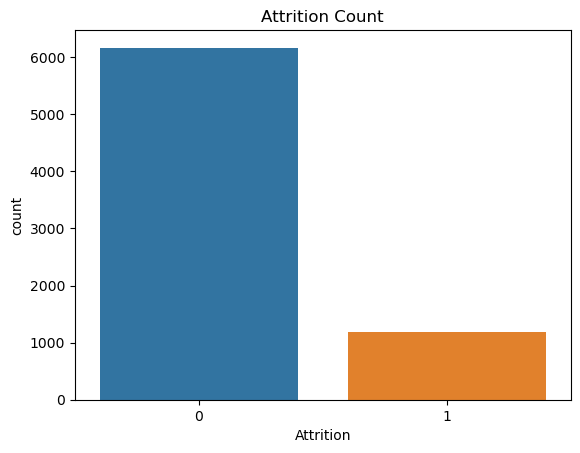

In [11]:
sns.countplot(data=df, x='Attrition')
plt.title("Attrition Count")


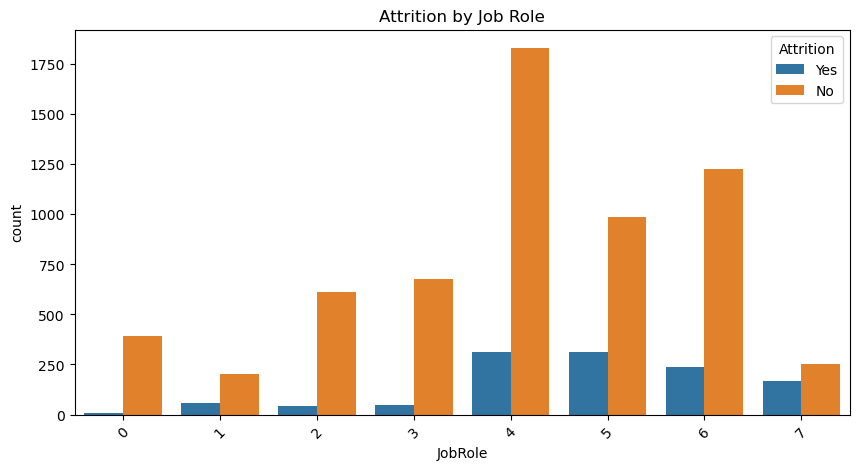

In [12]:
plt.figure(figsize=(10, 5))

# Convert numeric Attrition to string temporarily
sns.countplot(data=df.assign(Attrition=df['Attrition'].map({1: 'Yes', 0: 'No'})),
              x='JobRole', hue='Attrition')

plt.title("Attrition by Job Role")
plt.xticks(rotation=45)
plt.show()


In [13]:
df['Attrition'] = df['Attrition'].map({1: 'Yes', 0: 'No'})


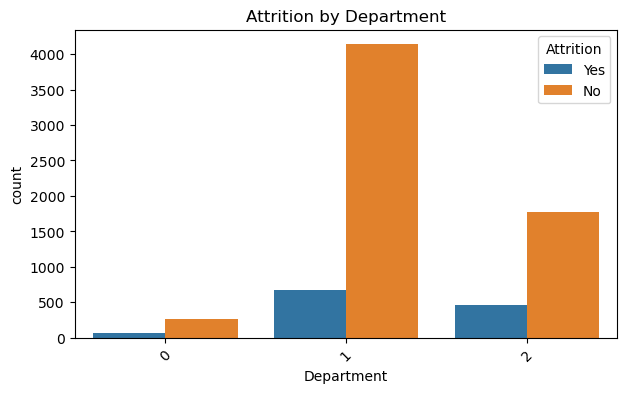

In [14]:
# Example for Department
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='Department', hue='Attrition')
plt.title("Attrition by Department")
plt.xticks(rotation=45)
plt.show()

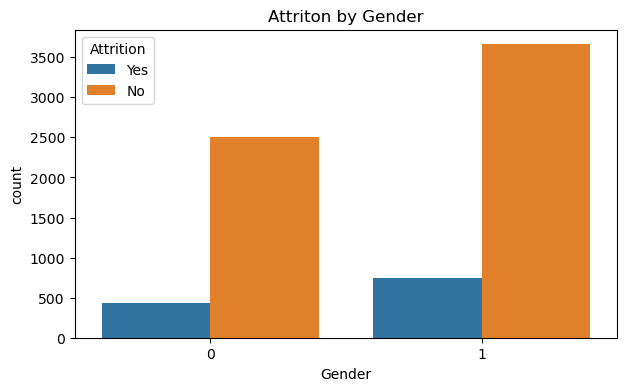

In [15]:
#example for Gender
plt.figure(figsize=(7,4))
sns.countplot(data=df,x='Gender',hue='Attrition')
plt.title("Attriton by Gender")
plt.show()

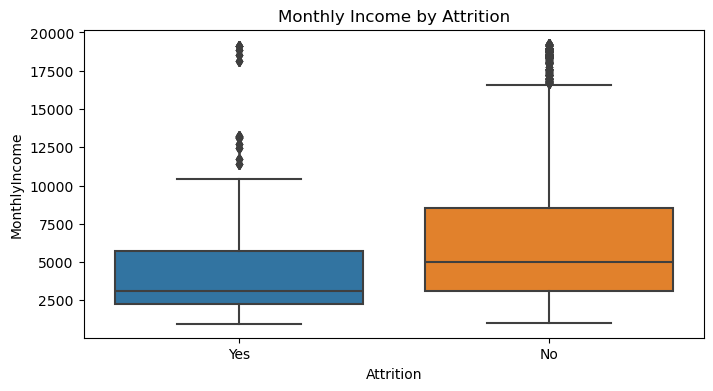

In [16]:
# MonthlyIncome vs Attrition
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome')
plt.title("Monthly Income by Attrition")
plt.show()

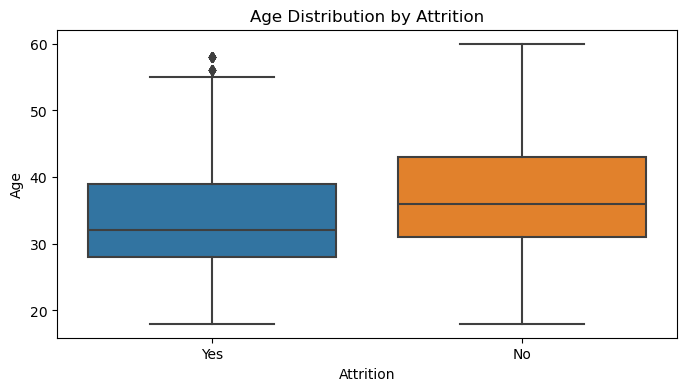

In [17]:
# Age vs Attrition
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x='Attrition', y='Age')
plt.title("Age Distribution by Attrition")
plt.show()

## Step 3 ✂️ Train-Test Split  
### Dividing the Dataset into Training and Testing Sets for Model Evaluation


In [18]:
# divide the data for training and testing size
from sklearn.model_selection import train_test_split
X=df.drop('Attrition',axis=1)
y=df['Attrition']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

## Step 4 🧠 Model Training  
### Building and Training the Machine Learning Model to Predict Employee Attrition



In [20]:
# train the 1st model on LogisticRegression
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix
model1=LogisticRegression(max_iter=10000)
model1.fit(X_train,y_train)

y_pred1=model1.predict(X_test)

print("Accuracy:",accuracy_score(y_test, y_pred1))
print("\nClassification Report:\n",classification_report(y_test, y_pred1))

Accuracy: 0.8795918367346939

Classification Report:
               precision    recall  f1-score   support

          No       0.90      0.97      0.93      1254
         Yes       0.68      0.35      0.46       216

    accuracy                           0.88      1470
   macro avg       0.79      0.66      0.70      1470
weighted avg       0.86      0.88      0.86      1470



In [21]:
# train the 2nd model on support vector machine algorithm
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

#standardize features for SVM
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

#train SVM model
svm_model=SVC(kernel='rbf',random_state=42)
svm_model.fit(X_train_scaled,y_train)

# Make predictions
y_pred_svm = svm_model.predict(X_test_scaled)

# evaluate performance
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))





Accuracy: 0.9693877551020408

Classification Report:
               precision    recall  f1-score   support

          No       0.97      1.00      0.98      1254
         Yes       0.98      0.81      0.89       216

    accuracy                           0.97      1470
   macro avg       0.97      0.90      0.93      1470
weighted avg       0.97      0.97      0.97      1470



In [22]:
import pickle

In [23]:
# Save the SVM model
with open('svm_model.pkl','wb')as model_file:
    pickle.dump(svm_model,model_file)

In [24]:
with open('scaler.pkl', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)

In [25]:

print("SVM model and scaler saved as pickle files.")

SVM model and scaler saved as pickle files.
